<a href="https://colab.research.google.com/github/KarenTatianaSalazar/analisis-spearman-hidratacion-saciedad/blob/main/analisis_spearman_hidratacion_saciedad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Hidratación y Saciedad: un Análisis Correlacional de Spearman sobre el Dataset Estimation of Obesity Levels**

### **Autor:** Karen Tatiana Salazar Sepúlveda **Fecha:** 11/09/2025 **Contexto:** Desarrollado durante el primer semestre de la Maestría en Ciencia de Datos de la Universidad Autónoma de Bucaramanga - UNAB
---

### **Descripción general**

El presente caso de estudio se centra en el análisis de la Hipótesis de la Correlación Inversa entre Hidratación y Saciedad, enfocándose en la relación entre el consumo diario de agua y la frecuencia de consumo de alimentos entre comidas.

Las variables Consumo_Agua (CH2O) y Comida_Entre_Horas (CAEC), analizadas de forma aislada, resultan insuficientes para establecer una relación confiable entre hidratación y saciedad, ya que existen individuos con alto consumo de agua que presentan alta frecuencia de ingesta entre comidas, y viceversa, lo que vuelve ambiguo cualquier análisis basado en una sola variable.

Esta investigación propone que la clave no reside en la magnitud de una medida única, sino en la asociación monotónica entre ellas. Se plantea que a mayor consumo de agua, menor debería ser la frecuencia de consumo de alimentos entre horas, reflejando una mayor saciedad fisiológica.

Para ello se utilizará el dataset "Estimation of Obesity Levels Based On Eating Habits and Physical Condition" (UCI Machine Learning), que contiene 2111 registros y 17 atributos de individuos de México, Perú y Colombia. La variable de hidratación es Consumo_Agua y el indicador de saciedad es Comida_Entre_Horas.

Dado que las variables son de naturaleza ordinal y categórica y no cumplen los supuestos de normalidad y linealidad de Pearson, se empleará la prueba de correlación de Spearman, técnica no paramétrica que evalúa la relación monotónica entre variables. El coeficiente ρ permitirá determinar si existe una asociación inversa y estadísticamente significativa entre hidratación y saciedad, constituyendo un indicador más robusto que cualquier medida individual.

**Nombre del dataset:**

Estimation of Obesity Levels Based On Eating Habits and Physical Condition  
(Estimación de los niveles de obesidad a partir de los hábitos alimenticios y la condición física)



**Fuente de obtención:**

Dataset disponible en la plataforma (Kaggle): https://www.kaggle.com/datasets/aravindpcoder/obesity-or-cvd-risk-classifyregressorcluster  

**Referencia del estudio original:**

Palechor, F. M., & de la Hoz, A. (2019). Dataset for estimation of obesity levels based on eating habits and physical condition in individuals from Colombia, Peru and Mexico. Data in Brief, 25, 104344. https://doi.org/10.1016/j.dib.2019.104344





## **Planteamiento del problema**

La hidratación y la saciedad son dos procesos fisiológicos fundamentales que influyen directamente en la salud metabólica de las personas. Diversos estudios sugieren que existe una relación inversa entre ambas variables: a mayor nivel de hidratación, menor sensación de hambre o mayor sensación de saciedad; y a menor ingesta de agua, mayor podría ser la ingesta calórica.

Sin embargo, en la práctica cotidiana y en el ámbito clínico, esta relación no siempre se manifiesta de forma clara. Muchas personas confunden la sed con el hambre, lo que las lleva a consumir alimentos cuando en realidad su organismo demanda líquidos. Esta confusión puede contribuir al aumento de peso, a una hidratación inadecuada y a trastornos metabólicos asociados.

Además, existe una brecha en la literatura respecto a cómo la hidratación, medida en parámetros objetivos como osmolaridad urinaria, color de orina o ingesta hídrica registrada, se correlaciona con marcadores de saciedad (como ghrelina, leptina o escalas visuales analógicas de hambre) en poblaciones específicas, lo que dificulta establecer conclusiones generalizables y aplicables a la práctica clínica o nutricional.

**Pregunta de investigación:**

¿Existe una correlación inversa entre el nivel de hidratación y la sensación de saciedad en adultos?

## **Limpieza y preparación de datos**

Antes de iniciar el análisis estadístico, se realizaron diferentes procedimientos de limpieza y validación con el fin de garantizar la consistencia e integridad del conjunto de datos.

*   **Valores faltantes:** Se verificó un 0% de registros nulos, por lo que no fue necesario aplicar técnicas de imputación.
*   **Traducción y renombramiento:** Las columnas fueron traducidas y renombradas al español para mejorar la legibilidad y facilitar la interpretación de los resultados dentro del contexto del estudio.
*   **Integridad de tipos de datos:** Se validó que las variables representadas como float64 correspondieran a atributos afectados por el proceso de sobremuestreo mediante SMOTE, asegurando su interpretación como escalas continuas de intensidad o frecuencia.
*  **Detección de valores atípicos:** Se inspeccionaron los rangos de Edad, Peso y Estatura, verificando que los registros se mantuvieran dentro de límites biológicamente consistentes.
*   **Eliminación de duplicados:** Se eliminaron 24 registros idénticos que no aportaban información adicional al análisis y podían generar distorsiones en frecuencias y medidas estadísticas.

### **Justificación de las decisiones**

**Preservación de valores decimales**

Se optó por conservar los valores decimales presentes en variables conductuales como Consumo de Vegetales, Actividad Física y Consumo de Agua. Debido a que estas variables fueron transformadas numéricamente y posteriormente sometidas a sobremuestreo mediante SMOTE, el redondeo de los valores habría eliminado parte de la variabilidad generada durante el proceso de balanceo, reduciendo la sensibilidad estadística del análisis.

### 3.1 Cargar archivo

In [ ]:
#Para esta actividad se importarán las siguientes librerías:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import chi2_contingency
import seaborn as sns
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import LabelEncoder

In [ ]:
path = kagglehub.dataset_download("aravindpcoder/obesity-or-cvd-risk-classifyregressorcluster")
print(os.listdir(path))
csv_path = os.path.join(path, 'ObesityDataSet.csv')
df = pd.read_csv(csv_path)
df

Using Colab cache for faster access to the 'obesity-or-cvd-risk-classifyregressorcluster' dataset.
['ObesityDataSet.csv']


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [ ]:
df_2= df.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

### 3.2 Renombrar columnas

In [ ]:
nuevos_nombres= {
    'Gender': 'Genero',
    'Age': 'Edad',
    'Height': 'Estatura',
    'Weight': 'Peso',
    'family_history_with_overweight': 'Antecedentes_Familiares',
    'FAVC': 'Consumo_Calorico_Frecuente',
    'FCVC': 'Consumo_Vegetales',
    'NCP': 'Comidas_Principales',
    'CAEC': 'Comida_Entre_Horas',
    'SMOKE': 'Fumador',
    'CH2O': 'Consumo_Agua',
    'SCC': 'Monitoreo_Calorias',
    'FAF': 'Actividad_Fisica',
    'TUE': 'Tiempo_Dispositivos',
    'CALC': 'Consumo_Alcohol',
    'MTRANS': 'Transporte',
    'NObeyesdad': 'Nivel_Obesidad'
}
df = df.rename(columns=nuevos_nombres)
df.head()

,Genero,Edad,Estatura,Peso,Antecedentes_Familiares,Consumo_Calorico_Frecuente,Consumo_Vegetales,Comidas_Principales,Comida_Entre_Horas,Fumador,Consumo_Agua,Monitoreo_Calorias,Actividad_Fisica,Tiempo_Dispositivos,Consumo_Alcohol,Transporte,Nivel_Obesidad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### 3.3 Pasar variables tipo objeto a string

In [ ]:
cols = ["Genero","Antecedentes_Familiares","Consumo_Calorico_Frecuente","Comida_Entre_Horas","Fumador","Monitoreo_Calorias","Consumo_Alcohol","Transporte","Nivel_Obesidad"]
df[cols] = df[cols].astype("string")

### 3.4 Revisar opciones de las variables categoricas

In [ ]:
variables_cat = df.select_dtypes(include='string').columns

for column in variables_cat:

    tabla = df[column].value_counts().reset_index()
    tabla.columns = [column, "Frecuencia"]

    print(f"\n{'-'*40}")
    print(f"Variable: {column}")
    print(tabla)


----------------------------------------
Variable: Genero
   Genero  Frecuencia
0    Male        1068
1  Female        1043

----------------------------------------
Variable: Antecedentes_Familiares
  Antecedentes_Familiares  Frecuencia
0                     yes        1726
1                      no         385

----------------------------------------
Variable: Consumo_Calorico_Frecuente
  Consumo_Calorico_Frecuente  Frecuencia
0                        yes        1866
1                         no         245

----------------------------------------
Variable: Comida_Entre_Horas
  Comida_Entre_Horas  Frecuencia
0          Sometimes        1765
1         Frequently         242
2             Always          53
3                 no          51

----------------------------------------
Variable: Fumador
  Fumador  Frecuencia
0      no        2067
1     yes          44

----------------------------------------
Variable: Monitoreo_Calorias
  Monitoreo_Calorias  Frecuencia
0                

### 3.5 Pasar opciones a español

In [ ]:
traducciones = {
    'yes': 'Sí',
    'no': 'No',

    'Female': 'Femenino',
    'Male': 'Masculino',

    'Sometimes': 'A veces',
    'Frequently': 'Frecuentemente',
    'Always': 'Siempre',

    'Public_Transportation': 'Transporte_Publico',
    'Automobile': 'Automóvil',
    'Walking': 'Caminando',
    'Motorbike': 'Motocicleta',
    'Bike': 'Bicicleta',

    'Insufficient_Weight': 'Peso_Insuficiente',
    'Normal_Weight': 'Peso_Normal',
    'Overweight_Level_I': 'Sobrepeso_Nivel_I',
    'Overweight_Level_II': 'Sobrepeso_Nivel_II',
    'Obesity_Type_I': 'Obesidad_Tipo_I',
    'Obesity_Type_II': 'Obesidad_Tipo_II',
    'Obesity_Type_III': 'Obesidad_Tipo_III',
}

variables_categoricas = [
    'Genero',
    'Consumo_Calorico_Frecuente',
    'Comida_Entre_Horas',
    'Fumador',
    'Monitoreo_Calorias',
    'Consumo_Alcohol',
    'Transporte',
    'Nivel_Obesidad',
    'Antecedentes_Familiares'
]

for col in variables_categoricas:
    df[col] = df[col].replace(traducciones)

In [ ]:
df

,Genero,Edad,Estatura,Peso,Antecedentes_Familiares,Consumo_Calorico_Frecuente,Consumo_Vegetales,Comidas_Principales,Comida_Entre_Horas,Fumador,Consumo_Agua,Monitoreo_Calorias,Actividad_Fisica,Tiempo_Dispositivos,Consumo_Alcohol,Transporte,Nivel_Obesidad
0,Femenino,21.000000,1.620000,64.000000,Sí,No,2.0,3.0,A veces,No,2.000000,No,0.000000,1.000000,No,Transporte_Publico,Peso_Normal
1,Femenino,21.000000,1.520000,56.000000,Sí,No,3.0,3.0,A veces,Sí,3.000000,Sí,3.000000,0.000000,A veces,Transporte_Publico,Peso_Normal
2,Masculino,23.000000,1.800000,77.000000,Sí,No,2.0,3.0,A veces,No,2.000000,No,2.000000,1.000000,Frecuentemente,Transporte_Publico,Peso_Normal
3,Masculino,27.000000,1.800000,87.000000,No,No,3.0,3.0,A veces,No,2.000000,No,2.000000,0.000000,Frecuentemente,Caminando,Sobrepeso_Nivel_I
4,Masculino,22.000000,1.780000,89.800000,No,No,2.0,1.0,A veces,No,2.000000,No,0.000000,0.000000,A veces,Transporte_Publico,Sobrepeso_Nivel_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Femenino,20.976842,1.710730,131.408528,Sí,Sí,3.0,3.0,A veces,No,1.728139,No,1.676269,0.906247,A veces,Transporte_Publico,Obesidad_Tipo_III
2107,Femenino,21.982942,1.748584,133.742943,Sí,Sí,3.0,3.0,A veces,No,2.005130,No,1.341390,0.599270,A veces,Transporte_Publico,Obesidad_Tipo_III
2108,Femenino,22.524036,1.752206,133.689352,Sí,Sí,3.0,3.0,A veces,No,2.054193,No,1.414209,0.646288,A veces,Transporte_Publico,Obesidad_Tipo_III
2109,Femenino,24.361936,1.739450,133.346641,Sí,Sí,3.0,3.0,A veces,No,2.852339,No,1.139107,0.586035,A veces,Transporte_Publico,Obesidad_Tipo_III


### 3.6 Tratamiento datos nulos

In [ ]:
nulos = df.isnull().sum()

print("VALORES NULOS POR COLUMNA: \n")
print(nulos.to_string())
print(f"\nTotal celdas nulas: {nulos.sum()}")

VALORES NULOS POR COLUMNA: 

Genero                        0
Edad                          0
Estatura                      0
Peso                          0
Antecedentes_Familiares       0
Consumo_Calorico_Frecuente    0
Consumo_Vegetales             0
Comidas_Principales           0
Comida_Entre_Horas            0
Fumador                       0
Consumo_Agua                  0
Monitoreo_Calorias            0
Actividad_Fisica              0
Tiempo_Dispositivos           0
Consumo_Alcohol               0
Transporte                    0
Nivel_Obesidad                0

Total celdas nulas: 0


El dataset no presenta valores nulos en ninguna columna. No se requiere imputación ni eliminación de filas. Esto es esperado porque el dataset ya pasó por limpieza previa antes de aplicar SMOTE

### 3.7 Detección y eliminación de duplicados

In [ ]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

if duplicados > 0:
    print("\nEjemplo de filas duplicadas:")
    print(df[df.duplicated(keep=False)].head(4).to_string())

Filas duplicadas encontradas: 24

Ejemplo de filas duplicadas:
       Genero  Edad  Estatura  Peso Antecedentes_Familiares Consumo_Calorico_Frecuente  Consumo_Vegetales  Comidas_Principales Comida_Entre_Horas Fumador  Consumo_Agua Monitoreo_Calorias  Actividad_Fisica  Tiempo_Dispositivos Consumo_Alcohol          Transporte     Nivel_Obesidad
97   Femenino  21.0      1.52  42.0                      No                         No                3.0                  1.0     Frecuentemente      No           1.0                 No               0.0                  0.0         A veces  Transporte_Publico  Peso_Insuficiente
98   Femenino  21.0      1.52  42.0                      No                         No                3.0                  1.0     Frecuentemente      No           1.0                 No               0.0                  0.0         A veces  Transporte_Publico  Peso_Insuficiente
105  Femenino  25.0      1.57  55.0                      No                         Sí        

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(2087, 17)

Se eliminaron 24 filas duplicadas exactas. Registros idénticos no aportan información adicional al análisis y pueden distorsionar frecuencias y estadísticas.

### 3.8 Tratamiento variables categoricas

Durante la exploración del dataset y la revisión de la literatura asociada, se identificó que el conjunto de datos utilizado no corresponde al dataset original, sino a una versión modificada con una menor cantidad de muestras. Debido a esta limitación, los autores aplicaron la técnica SMOTE (Synthetic Minority Over-sampling Technique) con el objetivo de generar observaciones sintéticas y balancear las clases del conjunto de datos.

Para implementar esta técnica, algunas variables categóricas ordinales fueron transformadas a representaciones numéricas basadas en rangos. Sin embargo, al aplicar SMOTE sobre este tipo de variables, se generaron valores intermedios artificiales (decimales) que no pertenecen a las categorías originales definidas en el dataset.

#### 3.8.1 Visualización ANTES del tratamiento

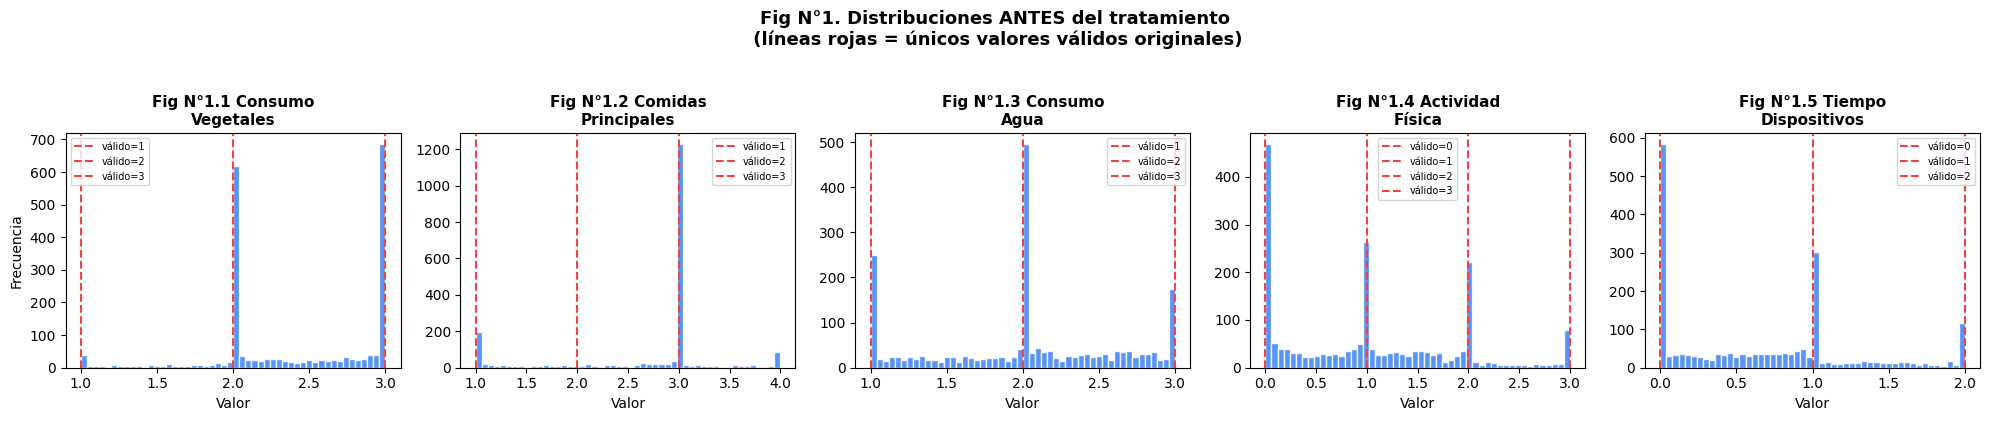

In [ ]:
VARS_SMOTE = ['Consumo_Vegetales', 'Comidas_Principales', 'Consumo_Agua','Actividad_Fisica', 'Tiempo_Dispositivos']
df_antes = df[VARS_SMOTE].copy()
VALORES_VALIDOS = {'Consumo_Vegetales':   [1, 2, 3],'Comidas_Principales': [1, 2, 3], 'Consumo_Agua':        [1, 2, 3],'Actividad_Fisica':    [0, 1, 2, 3],'Tiempo_Dispositivos': [0, 1, 2]}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Fig N°1. Distribuciones ANTES del tratamiento\n (líneas rojas = únicos valores válidos originales)',fontsize=13, fontweight='bold', y=1.04)

nombres_cortos = {'Consumo_Vegetales':   'Fig N°1.1 Consumo\nVegetales','Comidas_Principales': 'Fig N°1.2 Comidas\nPrincipales','Consumo_Agua':        'Fig N°1.3 Consumo\nAgua','Actividad_Fisica':    'Fig N°1.4 Actividad\nFísica','Tiempo_Dispositivos': 'Fig N°1.5 Tiempo\nDispositivos'}

for ax, var in zip(axes, VARS_SMOTE):
    ax.hist(df[var], bins=50, color='#3b82f6', edgecolor='white', alpha=0.85)
    for v in VALORES_VALIDOS[var]:
        ax.axvline(v, color='#ef4444', linestyle='--', linewidth=1.5, label=f'válido={v}')
    ax.set_title(nombres_cortos[var], fontsize=11, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia' if var == 'Consumo_Vegetales' else '')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

####3.8.2 Tratamiento de datos

In [ ]:
def asignar_valor_valido(x, valores_validos):
    arr = np.array(valores_validos)
    idx = np.argmin(np.abs(arr - x))
    return int(arr[idx])


def calcular_woe_iv(df, variable, target, valores_validos):
    total_e  = df[target].sum()
    total_ne = (1 - df[target]).sum()

    cats = df[variable].apply(lambda x: asignar_valor_valido(x, valores_validos))

    filas = []
    for cat in sorted(np.unique(cats)):
        mask     = cats == cat
        n        = mask.sum()
        eventos  = df.loc[mask, target].sum()
        no_ev    = n - eventos

        dist_e   = max(eventos / total_e,  1e-10)
        dist_ne  = max(no_ev   / total_ne, 1e-10)

        woe = np.log(dist_e / dist_ne)
        iv  = (dist_e - dist_ne) * woe

        filas.append({
            'Categoria':  int(cat),
            'N':          n,
            'Eventos':    eventos,
            'No_Eventos': no_ev,
            'Dist_E':     round(dist_e,  4),
            'Dist_NE':    round(dist_ne, 4),
            'WoE':        round(woe, 4),
            'IV_parcial': round(iv,  4)
        })

    tabla = pd.DataFrame(filas)
    return tabla, round(tabla['IV_parcial'].sum(), 4)

In [ ]:
df['_target'] = df['Nivel_Obesidad'].isin([
    'Obesidad_Tipo_I',
    'Obesidad_Tipo_II',
    'Obesidad_Tipo_III']).astype(int)

print(f"Tabla N°1: Target → Obesos (1): {df['_target'].sum()}  |  No obesos (0): {(1-df['_target']).sum()}\n")

resultados_woe = {}
iv_totales     = {}

for var in VARS_SMOTE:

    tabla, iv = calcular_woe_iv(
        df,
        var,
        '_target',
        VALORES_VALIDOS[var])

    resultados_woe[var] = tabla
    iv_totales[var]     = iv

    print("─" * 55)
    print(f"{var} | IV Total = {iv:.4f}")
    print(tabla.to_string(index=False))
    print()

Tabla N°1: Target → Obesos (1): 972  |  No obesos (0): 1115

───────────────────────────────────────────────────────
Consumo_Vegetales | IV Total = 0.0925
 Categoria   N  Eventos  No_Eventos  Dist_E  Dist_NE     WoE  IV_parcial
         1 102       38          64  0.0391   0.0574 -0.3840      0.0070
         2 994      394         600  0.4053   0.5381 -0.2833      0.0376
         3 991      540         451  0.5556   0.4045  0.3174      0.0479

───────────────────────────────────────────────────────
Comidas_Principales | IV Total = 0.0384
 Categoria    N  Eventos  No_Eventos  Dist_E  Dist_NE     WoE  IV_parcial
         1  296      103         193  0.1060   0.1731 -0.4907      0.0329
         2  176       83          93  0.0854   0.0834  0.0235      0.0000
         3 1615      786         829  0.8086   0.7435  0.0840      0.0055

───────────────────────────────────────────────────────
Consumo_Agua | IV Total = 0.0828
 Categoria    N  Eventos  No_Eventos  Dist_E  Dist_NE     WoE  IV_parc

Para realizar el análisis WoE e IV se transformó la variable Nivel_Obesidad en un target binario. Esto permitió estudiar específicamente la relación entre las variables y la presencia de obesidad como evento 1 y y considerando el resto de categorías como no evento 0

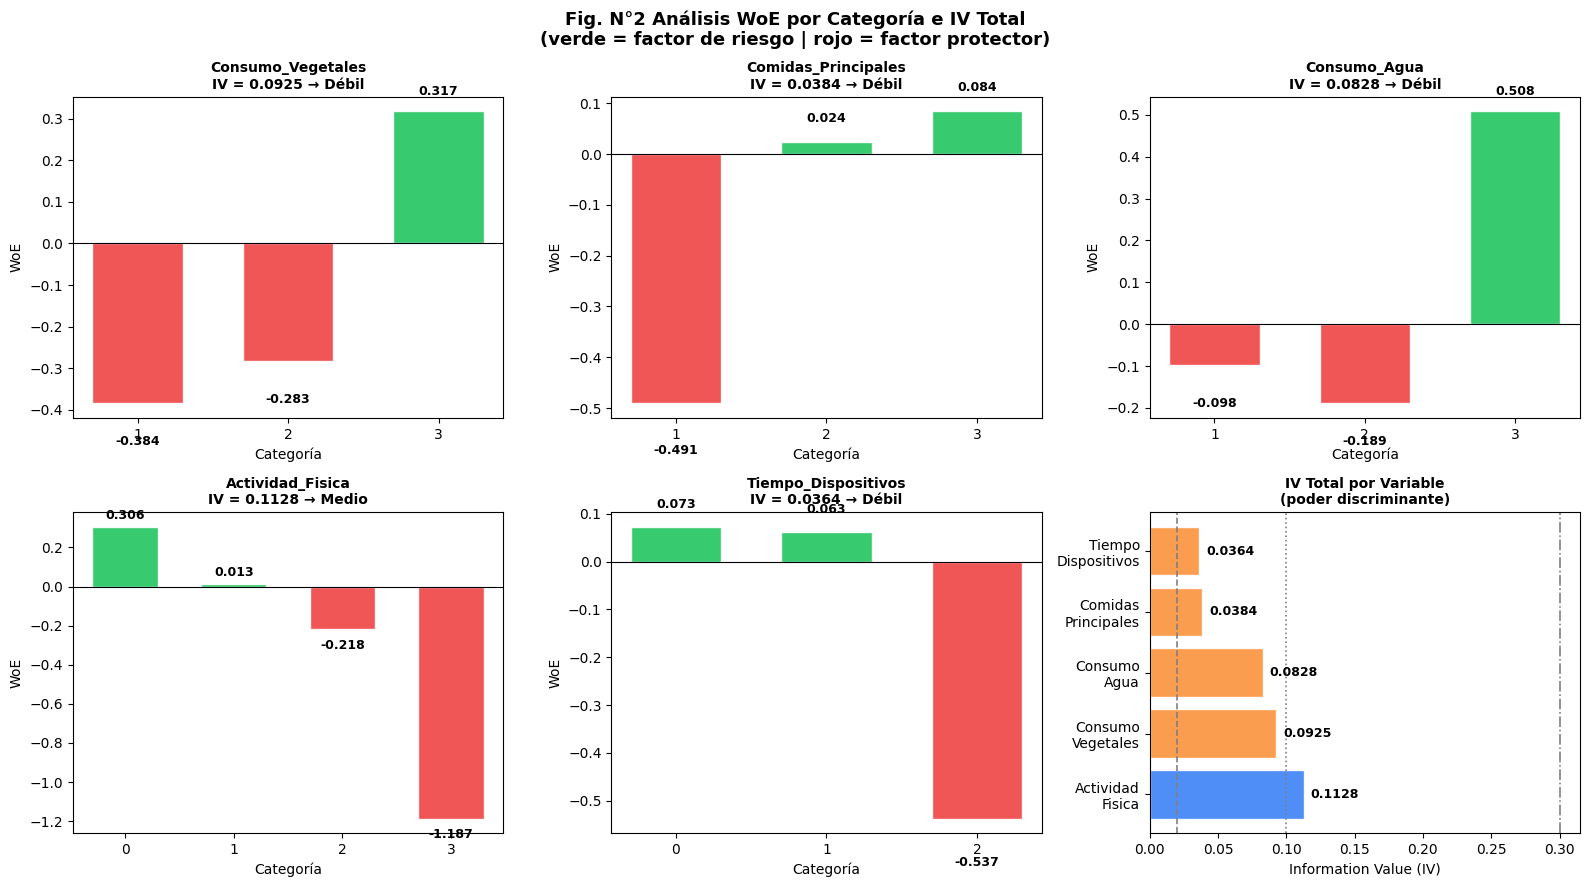

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Fig. N°2 Análisis WoE por Categoría e IV Total\n'
             '(verde = factor de riesgo | rojo = factor protector)',
             fontsize=13, fontweight='bold')

axes_flat = [axes[0][0], axes[0][1], axes[0][2], axes[1][0], axes[1][1]]

for ax, var in zip(axes_flat, VARS_SMOTE):
    tabla  = resultados_woe[var]
    cats   = [str(c) for c in tabla['Categoria']]
    woes   = tabla['WoE'].values
    colors = ['#22c55e' if w >= 0 else '#ef4444' for w in woes]

    bars = ax.bar(cats, woes, color=colors, edgecolor='white', alpha=0.9, width=0.6)
    ax.axhline(0, color='black', linewidth=0.8)

    for bar, w in zip(bars, woes):
        offset = 0.04 if w >= 0 else -0.10
        ax.text(bar.get_x() + bar.get_width() / 2,
                w + offset, f'{w:.3f}',
                ha='center', fontsize=9, fontweight='bold')

    nivel = ('Sin poder' if iv_totales[var] < 0.02 else
             'Débil'     if iv_totales[var] < 0.10 else
             'Medio'     if iv_totales[var] < 0.30 else 'Fuerte')
    ax.set_title(f'{var}\nIV = {iv_totales[var]:.4f} → {nivel}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Categoría')
    ax.set_ylabel('WoE')

# Panel de IV comparativo
ax_iv = axes[1][2]
vars_ord  = sorted(VARS_SMOTE, key=lambda v: iv_totales[v], reverse=True)
iv_vals   = [iv_totales[v] for v in vars_ord]
labels    = [v.replace('_', '\n') for v in vars_ord]
iv_colors = ['#22c55e' if v >= 0.30 else '#3b82f6' if v >= 0.10
             else '#fb923c' if v >= 0.02 else '#94a3b8' for v in iv_vals]

bars_iv = ax_iv.barh(labels, iv_vals, color=iv_colors, edgecolor='white', alpha=0.9)
for v, ls in [(0.02, '--'), (0.10, ':'), (0.30, '-.')]:
    ax_iv.axvline(v, color='gray', linestyle=ls, linewidth=1.2)
for bar, val in zip(bars_iv, iv_vals):
    ax_iv.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
               f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

ax_iv.set_title('IV Total por Variable\n(poder discriminante)',
                fontsize=10, fontweight='bold')
ax_iv.set_xlabel('Information Value (IV)')

plt.tight_layout()
plt.show()

El objetivo principal de las técnicas Weight of Evidence (WoE) e Information Value (IV) es evaluar la capacidad predictiva de las variables frente a un evento objetivo, permitiendo identificar qué variables y categorías aportan mayor información para discriminar entre las clases del problema. Estas técnicas son ampliamente utilizadas en modelos de clasificación, especialmente en regresión logística y análisis de riesgo, ya que ayudan tanto en la selección de variables como en la interpretación del comportamiento de las categorías dentro del modelo.

El eje horizontal representa las categorías de la variable y el eje vertical muestra el valor de WoE correspondiente a cada una. Los colores permiten identificar rápidamente el comportamiento de la categoría frente al evento objetivo en este caso, obesidad:

- Barras verdes: Se interpretan como posibles factores de . riesgo de obesidad. WoE positivo
- Barras rojas: Se interpretan como posibles NO factores de riesgo de obesidad. WoE negativo

Valores cercanos a 0 indican que la categoría tiene poca capacidad para diferenciar entre las clases

Valores positivos o negativos más alejados de 0 representan una mayor capacidad discriminante.

EL IV indica que tan útil es la variable completa para diferenciar entre las clases del problema. El IV se interpreta de la siguiente manera:

1. IV < 0.02 → Variable no útil
2. 0.02 ≤ IV < 0.1 → Poder predictivo débil
3. 0.1 ≤ IV < 0.3 → Poder predictivo medio
4. 0.3 ≤ IV < 0.5 → Poder predictivo fuerte
5. IV > 0.5 → Variable sospechosamente predictiva (posible overfitting)

El análisis mediante WoE e Information Value IV permitió evaluar la capacidad discriminante de las variables ordinales respecto a la condición de obesidad. La variable Actividad_Fisica presentó el mayor poder predictivo IV = 0.1128, mostrando además un comportamiento consistente con la literatura médica, donde mayores niveles de actividad física actúan como factor protector. Por otro lado, variables como Comidas_Principales mostraron un bajo poder discriminante, sugiriendo que subdivisiones adicionales de sus categorías aportarían poca información predictiva

In [ ]:
print(f"  {'Tabla N°2 TABLA DE DECISIÓN FINAL':^66}")
print("-" * 70)
print(f"  {'Variable':<25} {'IV':>7}  {'Nivel':<12}  Decisión")
print("  " + "─" * 65)

niveles = {v: ('Sin poder' if iv < 0.02 else 'Débil' if iv < 0.10
               else 'Medio' if iv < 0.30 else 'Fuerte')
           for v, iv in iv_totales.items()}

for var in sorted(VARS_SMOTE, key=lambda v: iv_totales[v], reverse=True):
    iv  = iv_totales[var]
    niv = niveles[var]
    vv  = VALORES_VALIDOS[var]
    print(f"  {var:<25} {iv:>7.4f}  {niv:<12}  → Enteros {vv}")


                  Tabla N°2 TABLA DE DECISIÓN FINAL                 
----------------------------------------------------------------------
  Variable                       IV  Nivel         Decisión
  ─────────────────────────────────────────────────────────────────
  Actividad_Fisica           0.1128  Medio         → Enteros [0, 1, 2, 3]
  Consumo_Vegetales          0.0925  Débil         → Enteros [1, 2, 3]
  Consumo_Agua               0.0828  Débil         → Enteros [1, 2, 3]
  Comidas_Principales        0.0384  Débil         → Enteros [1, 2, 3]
  Tiempo_Dispositivos        0.0364  Débil         → Enteros [0, 1, 2]


La tabla resume el resultado del proceso de limpieza aplicado a las variables ordinales afectadas por SMOTE.Se muestra  para cada variable su IV, el nivel de capacidad predictiva asociado según:

| IV | Nivel |
|---|---|
| < 0.02 | Sin poder |
| 0.02 – 0.10 | Débil |
| 0.10 – 0.30 | Medio |
| > 0.30 | Fuerte |

Actividad_Fisica presentó el mayor poder discriminatorio IV = 0.1128, clasificándose con un nivel predictivo medio y mostrando una relación consistente con la obesidad. Las variables como Consumo_Vegetales, Consumo_Agua, Comidas_Principales y Tiempo_Dispositivos presentaron un poder predictivo débil, aunque conservaron cierta capacidad para diferenciar entre obesidad y no obesidad.

#### 3.8.3 Visualización DESPUÉS del tratamiento

In [ ]:
for var in VARS_SMOTE:
    df[var] = df[var].apply(
        lambda x: asignar_valor_valido(x, VALORES_VALIDOS[var]))
    resultados_woe = {}
iv_totales = {}

for var in VARS_SMOTE:
    tabla, iv = calcular_woe_iv(df, var, '_target', VALORES_VALIDOS[var])

    resultados_woe[var] = tabla
    iv_totales[var] = iv

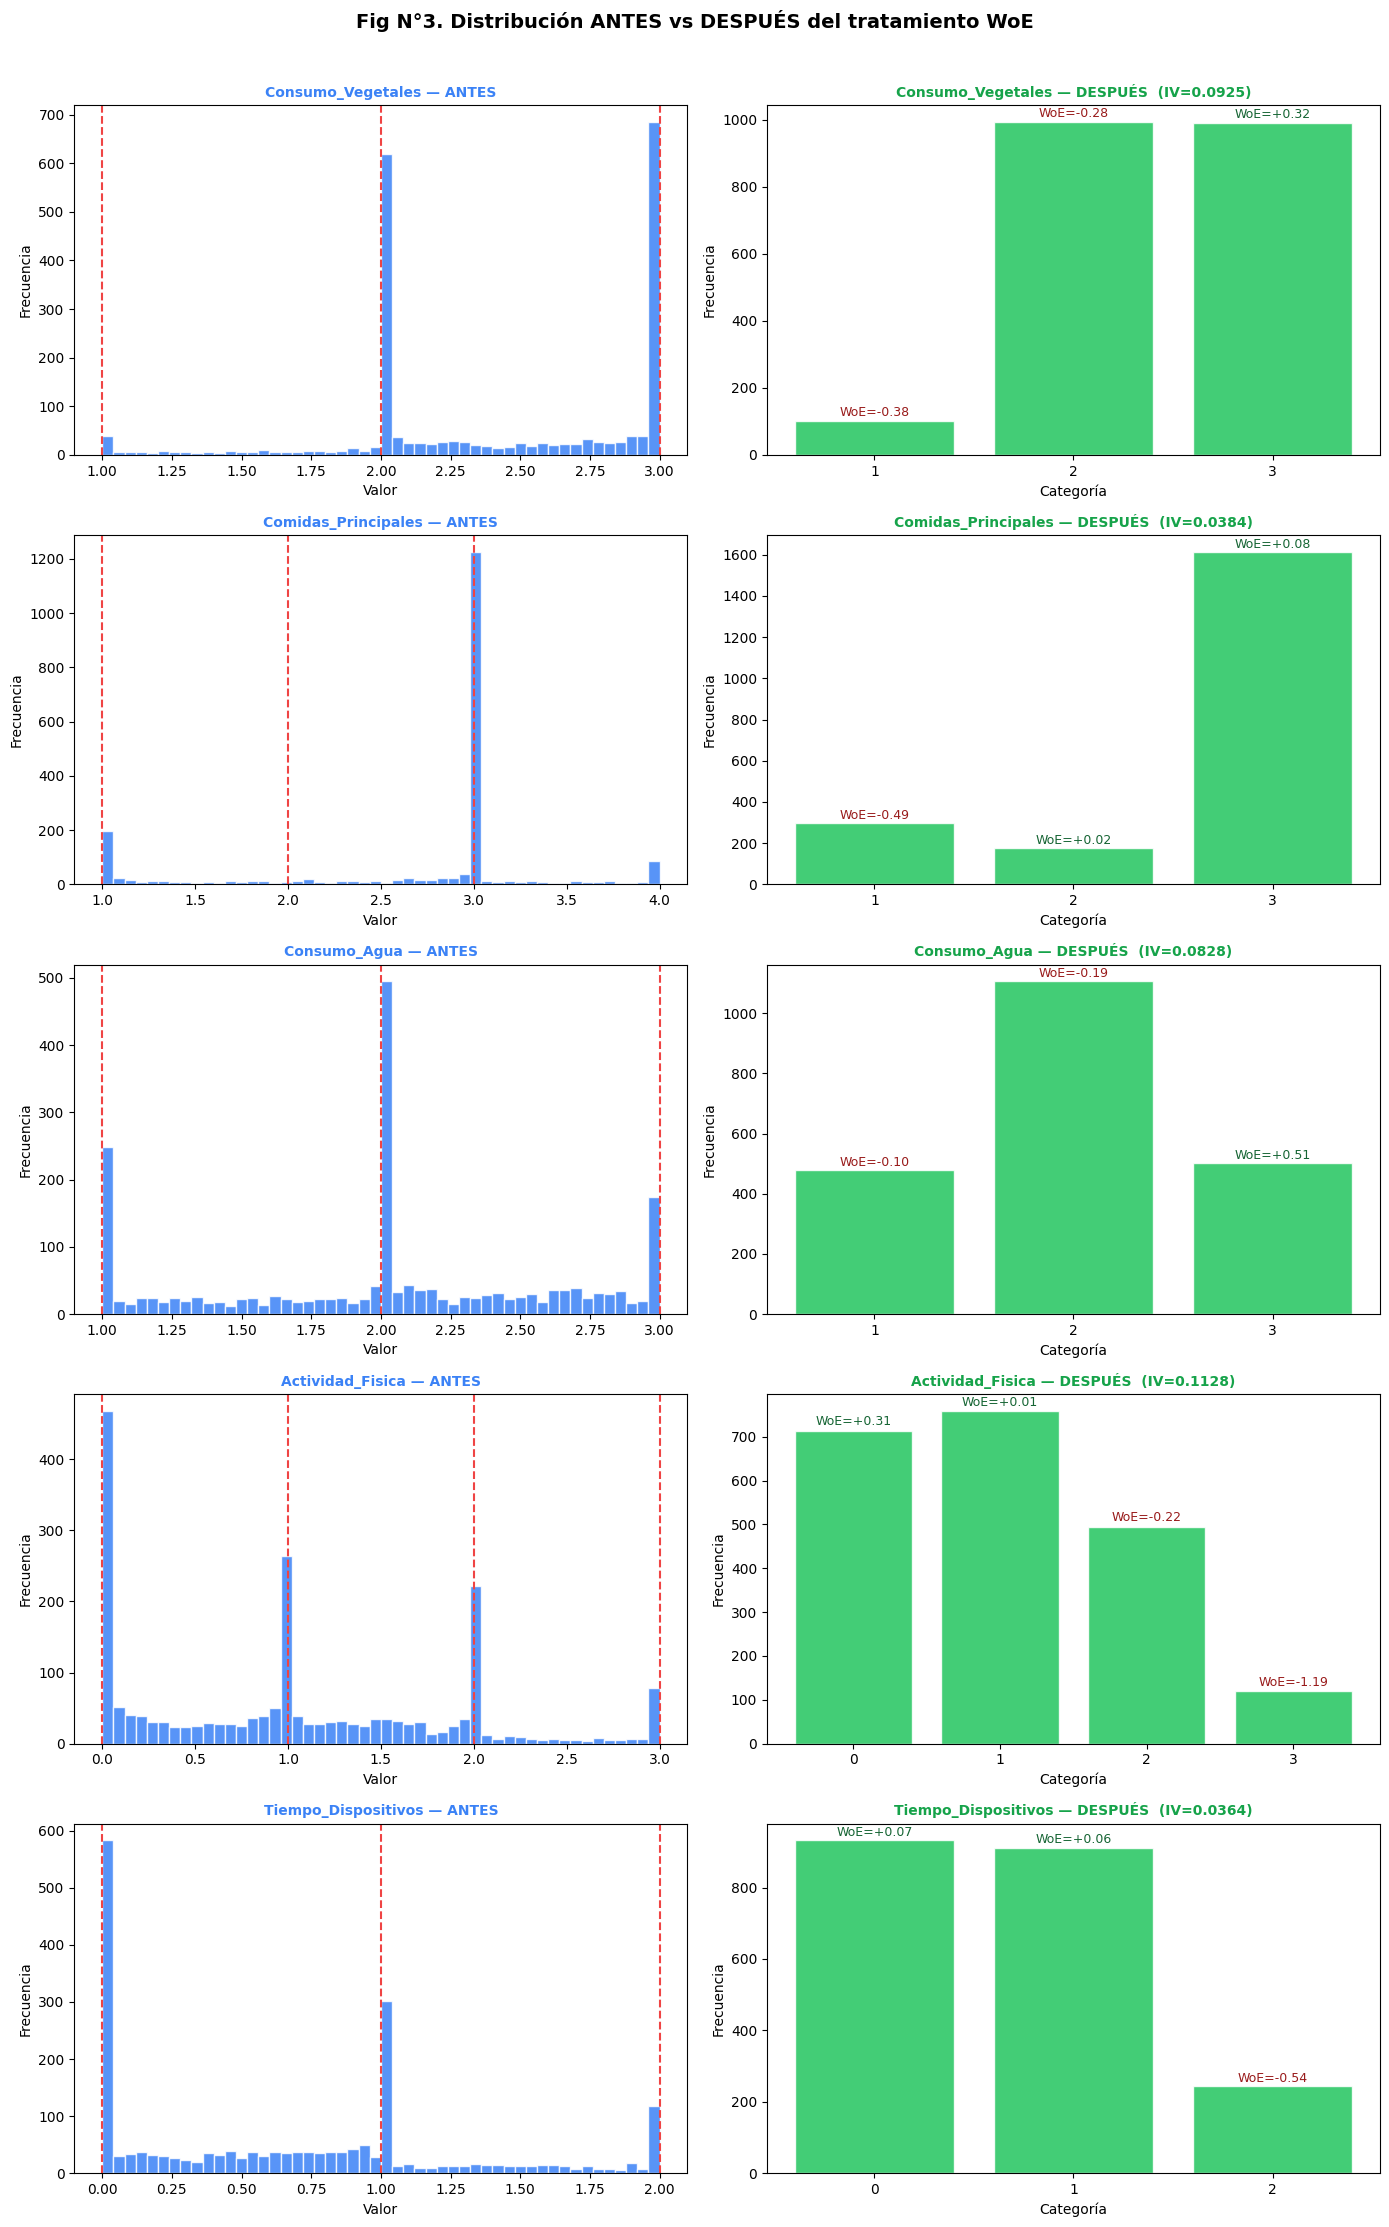

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(14, 22))
fig.suptitle('Fig N°3. Distribución ANTES vs DESPUÉS del tratamiento WoE',
             fontsize=14, fontweight='bold', y=1.01)

for i, var in enumerate(VARS_SMOTE):

    ax_a = axes[i][0]
    ax_a.hist(df_antes[var], bins=50, color='#3b82f6', edgecolor='white', alpha=0.85)
    for v in VALORES_VALIDOS[var]:
        ax_a.axvline(v, color='#ef4444', linestyle='--', linewidth=1.5)
    ax_a.set_title(f'{var} — ANTES', fontsize=10, fontweight='bold', color='#3b82f6')
    ax_a.set_xlabel('Valor')
    ax_a.set_ylabel('Frecuencia')

    ax_d = axes[i][1]
    counts = df[var].value_counts().sort_index()
    bars   = ax_d.bar([str(int(c)) for c in counts.index],
                      counts.values,
                      color='#22c55e', edgecolor='white', alpha=0.85)

    tabla_woe = resultados_woe[var].copy()
    tabla_woe['Categoria'] = tabla_woe['Categoria'].astype(int)
    tabla_woe = tabla_woe.set_index('Categoria')

    for bar, cat in zip(bars, counts.index):
        cat_int = int(cat)   # forzar a int nativo
        w    = tabla_woe.loc[cat_int, 'WoE']
        sign = '+' if w >= 0 else ''
        ax_d.text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + 5,
                  f'WoE={sign}{w:.2f}',
                  ha='center', va='bottom', fontsize=9,
                  color='#166534' if w >= 0 else '#991b1b')

    ax_d.set_title(f'{var} — DESPUÉS  (IV={iv_totales[var]:.4f})',
                   fontsize=10, fontweight='bold', color='#16a34a')
    ax_d.set_xlabel('Categoría')
    ax_d.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

En todas las variables analizadas, los datos después del tratamiento resultan más adecuados para el análisis, y esto se evidencia claramente en las gráficas. En el caso de Consumo_Vegetales, Consumo_Agua y Comidas_Principales, las distribuciones antes del tratamiento presentan picos muy pronunciados exactamente sobre los valores enteros válidos (1, 2 y 3), acompañados de una dispersión de valores decimales entre estas categorías con frecuencias considerablemente menores. Por ejemplo, en Consumo_Agua, los valores decimales entre 1 y 2 apenas superan los 30 registros por intervalo, mientras que el pico en la categoría 2 alcanza aproximadamente 500 registros. Esto sugiere que SMOTE generó valores interpolados que no modifican la forma general de la distribución, sino que introducen ruido continuo entre categorías que originalmente eran discretas.

En las variables Actividad_Fisica y Tiempo_Dispositivos, el efecto es aún más evidente. Antes del tratamiento se observan concentraciones principales en 0, 1 y 2, junto con una cola de valores decimales que se extiende hasta 3, generando una distribución que podría interpretarse erróneamente como continua y sesgada. Después del tratamiento, las distribuciones discretas permiten identificar patrones mucho más claros e interpretables. En particular, Actividad_Fisica presenta un comportamiento monotónico decreciente en el WoE, pasando de +0.31 a −1.19, patrón que no podía apreciarse con claridad en la distribución continua generada por los decimales artificiales.

Además, en ninguna de las variables el tratamiento produjo cambios drásticos en las frecuencias relativas entre categorías, ya que las proporciones generales se conservaron. Esto confirma que el ajuste al valor válido más cercano no introdujo sesgos significativos, sino que permitió restablecer la naturaleza categórica original de las variables, la cual había sido alterada artificialmente por SMOTE. Como resultado, se obtuvieron distribuciones más limpias, coherentes e interpretables, alineadas con el diseño original del instrumento de medición

In [ ]:
variables_categoricas = df.select_dtypes(include=['int', 'string']).columns

for col in variables_categoricas:
    print(f"\n{'-'*50}")
    print(f"Variable: {col}")
    print(sorted(df[col].unique()))


--------------------------------------------------
Variable: Genero
['Femenino', 'Masculino']

--------------------------------------------------
Variable: Antecedentes_Familiares
['No', 'Sí']

--------------------------------------------------
Variable: Consumo_Calorico_Frecuente
['No', 'Sí']

--------------------------------------------------
Variable: Consumo_Vegetales
[np.int64(1), np.int64(2), np.int64(3)]

--------------------------------------------------
Variable: Comidas_Principales
[np.int64(1), np.int64(2), np.int64(3)]

--------------------------------------------------
Variable: Comida_Entre_Horas
['A veces', 'Frecuentemente', 'No', 'Siempre']

--------------------------------------------------
Variable: Fumador
['No', 'Sí']

--------------------------------------------------
Variable: Consumo_Agua
[np.int64(1), np.int64(2), np.int64(3)]

--------------------------------------------------
Variable: Monitoreo_Calorias
['No', 'Sí']

-----------------------------------------

### 3.9 Tratamiento variables númericas

In [ ]:
df['Edad'] = df['Edad'].round().astype(int)

In [ ]:
df['Peso'] = df['Peso'].round(2)
df['Estatura'] = df['Estatura'].round(2)

In [ ]:
df

,Genero,Edad,Estatura,Peso,Antecedentes_Familiares,Consumo_Calorico_Frecuente,Consumo_Vegetales,Comidas_Principales,Comida_Entre_Horas,Fumador,Consumo_Agua,Monitoreo_Calorias,Actividad_Fisica,Tiempo_Dispositivos,Consumo_Alcohol,Transporte,Nivel_Obesidad,_target
0,Femenino,21,1.62,64.00,Sí,No,2,3,A veces,No,2,No,0,1,No,Transporte_Publico,Peso_Normal,0
1,Femenino,21,1.52,56.00,Sí,No,3,3,A veces,Sí,3,Sí,3,0,A veces,Transporte_Publico,Peso_Normal,0
2,Masculino,23,1.80,77.00,Sí,No,2,3,A veces,No,2,No,2,1,Frecuentemente,Transporte_Publico,Peso_Normal,0
3,Masculino,27,1.80,87.00,No,No,3,3,A veces,No,2,No,2,0,Frecuentemente,Caminando,Sobrepeso_Nivel_I,0
4,Masculino,22,1.78,89.80,No,No,2,1,A veces,No,2,No,0,0,A veces,Transporte_Publico,Sobrepeso_Nivel_II,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,Femenino,21,1.71,131.41,Sí,Sí,3,3,A veces,No,2,No,2,1,A veces,Transporte_Publico,Obesidad_Tipo_III,1
2083,Femenino,22,1.75,133.74,Sí,Sí,3,3,A veces,No,2,No,1,1,A veces,Transporte_Publico,Obesidad_Tipo_III,1
2084,Femenino,23,1.75,133.69,Sí,Sí,3,3,A veces,No,2,No,1,1,A veces,Transporte_Publico,Obesidad_Tipo_III,1
2085,Femenino,24,1.74,133.35,Sí,Sí,3,3,A veces,No,3,No,1,1,A veces,Transporte_Publico,Obesidad_Tipo_III,1


#### 3.9 Outliers

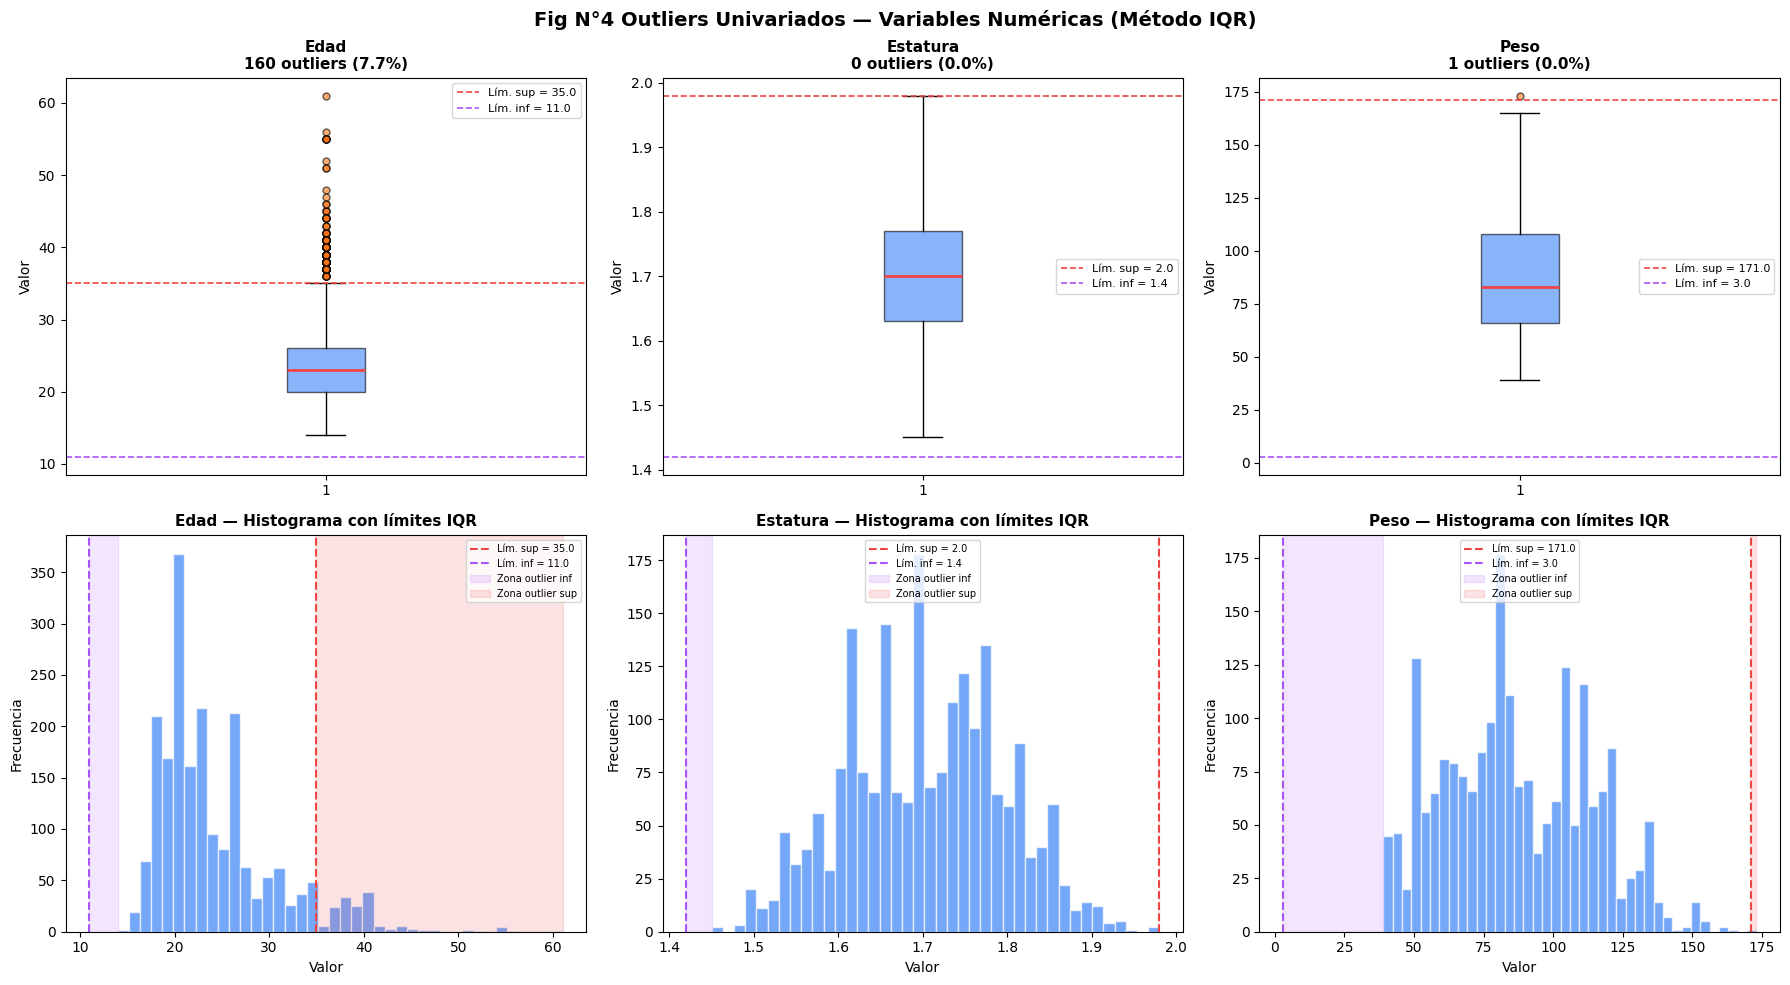

In [ ]:
vars_numericas = ['Edad', 'Estatura', 'Peso']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Fig N°4 Outliers Univariados — Variables Numéricas (Método IQR)',
             fontsize=14, fontweight='bold')

for i, var in enumerate(vars_numericas):
    datos = df[var]

    Q1  = datos.quantile(0.25)
    Q3  = datos.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers     = datos[(datos < lim_inf) | (datos > lim_sup)]
    n_outliers   = len(outliers)
    pct_outliers = n_outliers / len(datos) * 100

    ax_box = axes[0][i]
    bp = ax_box.boxplot(datos, vert=True, patch_artist=True,
                        boxprops=dict(facecolor='#3b82f6', alpha=0.6),
                        medianprops=dict(color='#ef4444', linewidth=2),
                        flierprops=dict(marker='o', color='#f97316',
                                        markerfacecolor='#f97316',
                                        markersize=5, alpha=0.6))
    ax_box.axhline(lim_sup, color='#ef4444', linestyle='--',
                   linewidth=1.2, label=f'Lím. sup = {lim_sup:.1f}')
    ax_box.axhline(lim_inf, color='#a855f7', linestyle='--',
                   linewidth=1.2, label=f'Lím. inf = {lim_inf:.1f}')
    ax_box.set_title(f'{var}\n{n_outliers} outliers ({pct_outliers:.1f}%)',
                     fontsize=11, fontweight='bold')
    ax_box.set_ylabel('Valor')
    ax_box.legend(fontsize=8)


    ax_hist = axes[1][i]
    ax_hist.hist(datos, bins=40, color='#3b82f6', edgecolor='white', alpha=0.7)
    ax_hist.axvline(lim_sup, color='#ef4444', linestyle='--',
                    linewidth=1.5, label=f'Lím. sup = {lim_sup:.1f}')
    ax_hist.axvline(lim_inf, color='#a855f7', linestyle='--',
                    linewidth=1.5, label=f'Lím. inf = {lim_inf:.1f}')

    # Sombrear zona de outliers
    ax_hist.axvspan(datos.min(), lim_inf, alpha=0.15, color='#a855f7',
                    label='Zona outlier inf')
    ax_hist.axvspan(lim_sup, datos.max(), alpha=0.15, color='#ef4444',
                    label='Zona outlier sup')
    ax_hist.set_title(f'{var} — Histograma con límites IQR',
                      fontsize=11, fontweight='bold')
    ax_hist.set_xlabel('Valor')
    ax_hist.set_ylabel('Frecuencia')
    ax_hist.legend(fontsize=7)

plt.tight_layout()
plt.show()

**Edad** es la variable con mayor presencia de outliers, con **167 registros (8.0%)** superando el límite superior de 35.1 años. El boxplot muestra una caja compacta concentrada entre los 19 y 26 años aproximadamente, con la mediana alrededor de los 23 años, mientras que la cola superior se extiende hasta los 61 años con una densidad importante de puntos atípicos visibles en naranja. El histograma confirma esto: la distribución está fuertemente sesgada a la derecha, con el grueso de la población entre 15 y 30 años y una cola larga hacia edades mayores que cruza ampliamente el límite superior. El límite inferior de 10.8 años no genera outliers, lo que indica que no hay registros de menores de edad extremadamente jóvenes en la muestra. Este comportamiento es esperable dado que el dataset proviene principalmente de población universitaria latinoamericana, donde la mayoría de participantes son adultos jóvenes y los casos de mayor edad representan excepciones dentro de la muestra.

**Estatura** presenta prácticamente **0 outliers relevantes** (1 registro, 0.0%), con un límite superior de 2.0 m y un límite inferior de 1.4 m que contienen casi la totalidad de los datos. El boxplot muestra una distribución simétrica y bien comportada centrada alrededor de 1.70 m, con bigotes que se extienden uniformemente en ambas direcciones. El histograma evidencia la distribución bimodal característica de la mezcla de géneros mencionada en el análisis exploratorio previo, con picos alrededor de 1.65 m y 1.75 m. La ausencia de outliers significativos indica que la estatura es la variable numéricamente más estable del dataset, sin valores extremos que comprometan el análisis.

**Peso** muestra un comportamiento similar a la estatura en términos de outliers formales: **1 registro (0.0%)** supera el límite superior de 171.0 kg, y el límite inferior de 3.0 kg no captura ningún caso. Sin embargo, el histograma revela algo importante que el conteo de outliers no captura: la distribución del peso es **multimodal y altamente dispersa**, con registros que van desde aproximadamente 40 kg hasta 170 kg y múltiples picos que reflejan las distintas subpoblaciones de niveles de obesidad. Esta amplitud del rango intercuartílico que genera un límite superior tan alto como 171 kg — implica que el método IQR no es sensible para detectar outliers en esta variable porque la variabilidad interna entre niveles de obesidad es tan grande que "absorbe" los valores extremos dentro de los límites. Esto sugiere que para el peso, un análisis de outliers estratificado por `Nivel_Obesidad` sería más informativo que el IQR global.

## **Hipótesis de la Correlación Inversa entre Hidratación y Saciedad**

El presente estudio analiza la relación entre el estado de hidratación y la autorregulación de la ingesta de alimentos. En la fisiología humana, las señales de sed y hambre a menudo comparten vías de procesamiento en el sistema nervioso central, lo que puede generar una interpretación errónea de las necesidades del organismo y derivar en un consumo innecesario de calorías. Al considerar que el agua genera una distensión gástrica inicial y contribuye a los mecanismos de saciedad, resulta fundamental evaluar si una hidratación adecuada reduce la tendencia al snacking o consumo de alimentos entre comidas.

Al realizar la exploración inicial de los datos en Figura 12 Matriz de Correlación de Spearman, se observa un coeficiente de correlación de Spearman de -0.13 entre el consumo de agua y la ingesta de alimentos entre horas. Si bien en los manuales de estadística tradicional este valor se clasifica como una correlación baja o casi inexistente, en el estudio del comportamiento humano un resultado así no debe desecharse de inmediato. Existe un mito popular muy extendido que afirma que 'beber agua quita el hambre'. Este hallazgo preliminar de 0.13, aunque débil, muestra una tendencia real. Esto justificó la decisión de profundizar mediante una prueba de hipótesis formal, con el objetivo de evaluar si esta sutil relación se debe al azar o si realmente confirma que el consumo de agua influye, aunque de forma leve, en el control del apetito.

Para indagar en este fenómeno, se plantean las siguientes hipótesis:

Hipótesis:

Hipótesis de Investigación ($H_1$): El nivel de hidratación influye significativamente en la conducta alimentaria; a mayor consumo de agua, menor es la frecuencia de ingesta de alimentos entre comidas (snacks).

Hipótesis Nula ($H_0$): El consumo de agua no tiene efecto sobre la frecuencia con la que una persona come entre horas. Ambas conductas son independientes.

**Tecnica:** Correlación de Spearman

**Justificación:** Para la validación de las hipótesis planteadas, se optó por un enfoque correlacional no paramétrico. Tras el análisis exploratorio y el tratamiento de los datos, se determinó que ambas variables poseen una naturaleza ordinal: la variable «Comida_Entre_Horas» y la variable «Consumo_Agua», esta última tras haber sido tratada en tres niveles jerárquicos de hidratación (1, 2 y 3). Debido a esto, se seleccionó el Coeficiente de Correlación de Spearman. Este método es el más óptimo para identificar la fuerza y la dirección de la relación entre variables basadas en rangos, permitiendo verificar si la modificación en una conducta se asocia de manera monotónica con la otra (Pan et al, 2013).

Asimismo, para el tratamiento estadístico se utilizaron los valores numéricos ordinales de la variable «Comida_Entre_Horas_Cod», los cuales asignan una escala de 0 a 3 (donde 0 representa 'No' y 3 representa 'Siempre'). Esto permitió jerarquizar la frecuencia de la conducta alimentaria de manera homóloga a los niveles de hidratación, facilitando el cálculo correcto de las relaciones estadísticas en el estudio

**Variables:** Consumo_Agua Y Comida_Entre_Horas

In [ ]:
contingency_table = pd.crosstab(df['Consumo_Agua'], df['Comida_Entre_Horas'])

orden_columnas = ['No', 'A veces', 'Frecuentemente', 'Siempre']
tabla_ordenada = contingency_table.loc[[1, 2, 3], orden_columnas]

tabla_ordenada

Comida_Entre_Horas,No,A veces,Frecuentemente,Siempre
Consumo_Agua,,,,
1,0,381,88,9
2,19,943,111,34
3,18,437,37,10


In [ ]:
df_verificacion_agua = df[['Consumo_Agua']].drop_duplicates().sort_values(by='Consumo_Agua')
print("   VERIFICACIÓN DE VALORES CONSUMO DE AGUA")
print(df_verificacion_agua.to_string(index=False))


   VERIFICACIÓN DE VALORES CONSUMO DE AGUA
 Consumo_Agua
            1
            2
            3


Como se observa en la auditoría y limpieza de los datos, la variable «Consumo_Agua» original registrada en litros diarios, la cual presentaba valores continuos con decimales fue sometida a un tratamiento de datos que reagrupó dicha información en una escala ordinal de tres niveles (1, 2 y 3) para representar rangos de hidratación. Este tratamiento no introduce un sesgo que altere la dirección o validez de los resultados, ya que preserva estrictamente la jerarquía original de los datos; esto garantiza que la prueba de correlación de Spearman funcione correctamente al evaluar la relación monotónica basada en rangos.

No obstante, este tratamiento de los datos implica una pérdida deliberada de variabilidad y precisión matemática, dado que unifica bajo un mismo nivel conductas individuales que originalmente mostraban sutiles diferencias en decimales. A cambio de sacrificar esa sensibilidad fina del dato continuo, el procedimiento ofrece la ventaja metodológica de neutralizar el impacto de posibles valores atípicos y estandarizar la variable «Consumo_Agua», permitiendo una interpretación conceptual más clara y directa del comportamiento de hidratación de los sujetos evaluados.

In [ ]:
mapeo_espanol = {'No': 0, 'A veces': 1, 'Frecuentemente': 2, 'Siempre': 3}
df['Comida_Entre_Horas_Cod'] = df['Comida_Entre_Horas'].map(mapeo_espanol)
df_verificacion = df[['Comida_Entre_Horas', 'Comida_Entre_Horas_Cod']].drop_duplicates().sort_values(by='Comida_Entre_Horas_Cod')

print("AUDITORÍA DE CODIFICACIÓN DE VARIABLES")
print(df_verificacion.to_string(index=False))


AUDITORÍA DE CODIFICACIÓN DE VARIABLES
Comida_Entre_Horas  Comida_Entre_Horas_Cod
                No                       0
           A veces                       1
    Frecuentemente                       2
           Siempre                       3


La variable «Comida_Entre_Horas» posee una naturaleza cualitativa ordinal, ya que sus categorías cualitativas (No, A veces, Frecuentemente, Siempre) siguen un orden lógico y jerárquico de intensidad o frecuencia. Para poder procesar matemáticamente esta información en pruebas estadísticas que requieren datos numéricos como el coeficiente de correlación de Spearman, es indispensable utilizar su versión codificada, «Comida_Entre_Horas_Cod». Esta transformación asigna un valor entero correlativo (del 0 al 3) a cada nivel, preservando rigurosamente la estructura de orden original de la conducta observada y permitiendo así el cálculo correcto de las relaciones estadísticas dentro del estudio.

In [ ]:
mapeo_espanol = {'No': 0, 'A veces': 1, 'Frecuentemente': 2, 'Siempre': 3}
df['Comida_Entre_Horas_Cod'] = df['Comida_Entre_Horas'].map(mapeo_espanol)

coef, p_value = stats.spearmanr(
    df['Consumo_Agua'],
    df['Comida_Entre_Horas_Cod'],
    nan_policy='omit'
)

print("-" * 30)
print(f"RESULTADOS ESTADÍSTICOS")
print("-" * 30)
print(f"Coeficiente de Spearman: {coef:.4f}")
print(f"Valor p: {p_value:.4e}")
print("-" * 30)

if p_value < 0.05:
    if coef < 0:
        print("CONCLUSIÓN: Hipótesis H1 cumplida. Existe una relación inversa significativa; a mayor nivel de hidratación, menor frecuencia de snacks.")
    else:
        print("CONCLUSIÓN: Relación significativa detectada, pero inversa a la hipótesis. A mayor nivel de hidratación, mayor frecuencia de snacks.")
else:
    print("CONCLUSIÓN: Hipótesis H0 mantenida. No existe una relación estadísticamente significativa entre el nivel de hidratación y el consumo de snacks.")

print("-" * 30)

------------------------------
RESULTADOS ESTADÍSTICOS
------------------------------
Coeficiente de Spearman: -0.1269
Valor p: 6.0411e-09
------------------------------
CONCLUSIÓN: Hipótesis H1 cumplida. Existe una relación inversa significativa; a mayor nivel de hidratación, menor frecuencia de snacks.
------------------------------


**Dirección de la relación:** El coeficiente de correlación de Spearman ($\rho = -0.1269$) presenta un signo negativo, lo que confirma de manera matemática una relación inversa o negativa entre las variables. A medida que aumenta el nivel de consumo de agua (hidratación), disminuye la frecuencia del consumo de snacks.

**Significancia estadística:** El valor p obtenido es de 6.0411 x 10^{-9}. Al ser drásticamente inferior al umbral estándar de significancia ($\alpha = 0.05$) , permite rechazar la Hipótesis Nula ($H_0$) con un altísimo nivel de confianza, demostrando que la relación observada no es obra del azar.

**Magnitud o fuerza**: Un valor absoluto de 0.1269 se clasifica metodológicamente como una correlación débil. Esto indica que, aunque el efecto del consumo de agua sobre la ingesta de snacks es real y constante, existen otros factores externos como psicológicos, ambientales o biológicos que también influyen en la conducta de picar entre comidas.

**Análisis de Resultados sobre la Correlación de Spearman**

Se observa una relación inversa estadísticamente significativa entre el consumo de agua (CH2O) y la frecuencia de ingesta de alimentos entre comidas (CAEC). El coeficiente de correlación de Spearman (\rho = -0.1269) confirma que ambas variables se mueven en direcciones opuestas. La significancia del resultado permite rechazar la Hipótesis Nula ($H_0$), estableciendo que la probabilidad de que este patrón sea producto del azar es prácticamente inexistente.

La robustez de este hallazgo se sustenta en un valor p extremadamente bajo (6.0411 x 10^{-9)), lo que garantiza la existencia real del fenómeno analizado. En cuanto a la magnitud del coeficiente (-0.1269), este se clasifica como una correlación de fuerza "débil". Sin embargo, es un resultado esperado y metodológicamente realista en el análisis de conductas humanas y nutricionales, donde la ingesta de alimentos es un fenómeno multicausal influenciado por factores psicológicos, biológicos, sociales y ambientales. Que la relación sea leve en intensidad no le resta validez; al contrario, demuestra que, incluso ante la presencia de múltiples variables intervinientes, el nivel de hidratación ejerce una influencia constante y medible sobre la conducta de consumo de snacks.

Si bien en los manuales de estadística tradicional este valor  -0.13  se clasifica como una correlación baja, en el estudio del comportamiento humano un resultado así no debería ser desechado tan fácilmente.

Al tratarse de dos conductas, se debe considerar lo planteado por Gignac y Szodorai (2016), quienes encontraron que en la literatura de la psicología la correlación promedio es de .19 y que los valores de .11 y .29 caen en los percentiles 25 y 75. Bajo esta evidencia, los autores proponen que una correlación de .10 es considerada pequeña y una de .20 típica, (Funder, D. C., & Ozer, D. J., 2019) por lo que un coeficiente de -0.13 entra en este rango esperable para el comportamiento, lo que justifica no descartar el hallazgo.



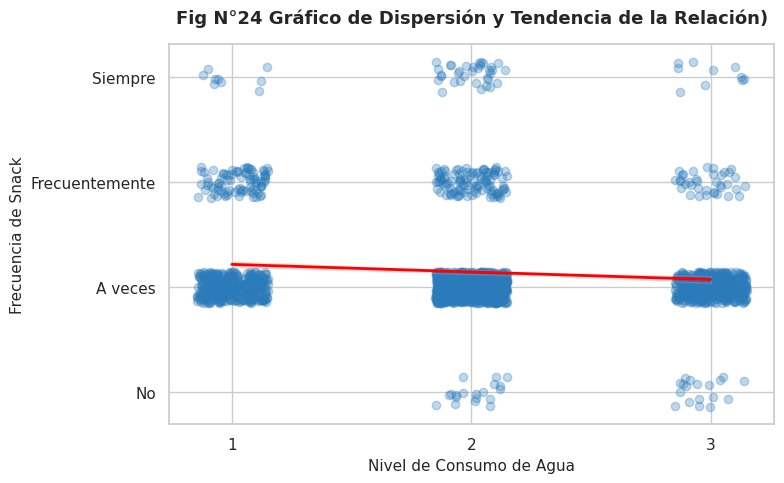

In [ ]:
plt.figure(figsize=(8, 5))

sns.regplot(
    x='Consumo_Agua',
    y='Comida_Entre_Horas_Cod',
    data=df,
    x_jitter=0.15, y_jitter=0.15,
    scatter_kws={'alpha':0.3, 'color': '#2b7bba'},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Fig N°24 Gráfico de Dispersión y Tendencia de la Relación)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Nivel de Consumo de Agua", fontsize=11)
plt.ylabel("Frecuencia de Snack", fontsize=11)
plt.xticks([1, 2, 3])
plt.yticks([0, 1, 2, 3], ['No', 'A veces', 'Frecuentemente', 'Siempre'])

plt.tight_layout()
plt.show()

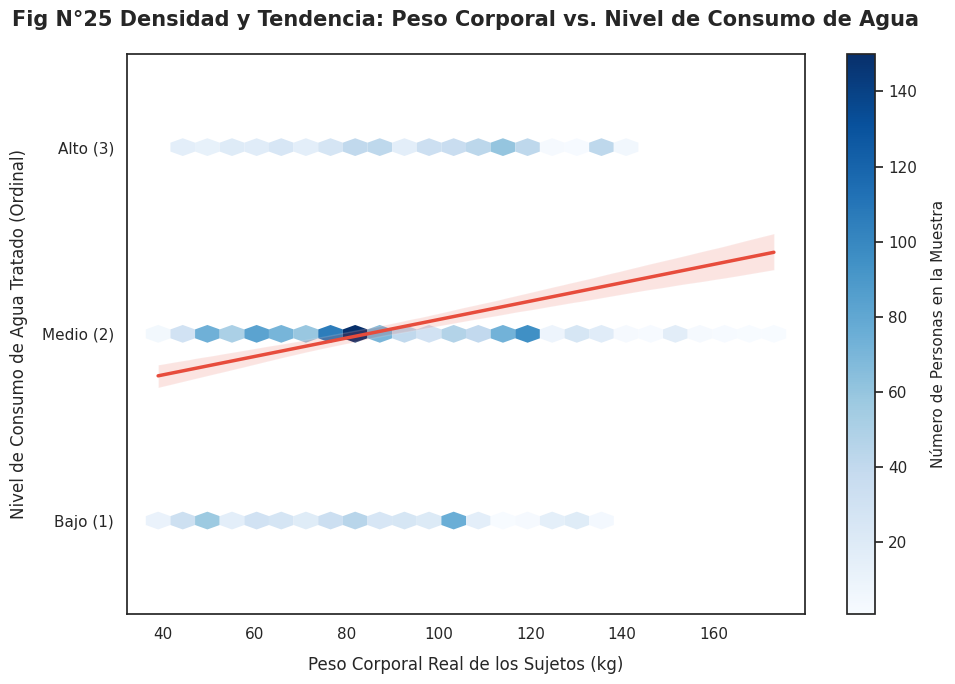

In [ ]:
sns.set_theme(style="white")
plt.figure(figsize=(10, 7))

hb = plt.hexbin(
    df["Peso"],
    df["Consumo_Agua"],
    gridsize=25,
    cmap="Blues",
    mincnt=1,
    edgecolors="none",
)

cb = plt.colorbar(hb)
cb.set_label("Número de Personas en la Muestra", fontsize=11, labelpad=10)

sns.regplot(
    data=df,
    x="Peso",
    y="Consumo_Agua",
    scatter=False,
    line_kws={"color": "#E74C3C", "linewidth": 2.5},
)

plt.title(
    "Fig N°25 Densidad y Tendencia: Peso Corporal vs. Nivel de Consumo de Agua",
    fontsize=15,
    pad=20,
    fontweight="bold",
)
plt.xlabel("Peso Corporal Real de los Sujetos (kg)", fontsize=12, labelpad=10)
plt.ylabel("Nivel de Consumo de Agua Tratado (Ordinal)", fontsize=12, labelpad=10)

plt.yticks([1, 2, 3], ["Bajo (1)", "Medio (2)", "Alto (3)"])
plt.ylim(0.5, 3.5)

plt.tight_layout()
plt.show()

**Análisis Integrado: Consumo de Agua, Peso Corporal y Frecuencia de Snacks**

Al cruzar los hallazgos de la figura 24  de Dispersión y Tendencia de la Relación y la figura 25 de Densidad y Tendencia: Peso Corporal vs. Nivel de Consumo de Agua bajo los parámetros de recomendación de la Sociedad Española de Dietética y Ciencias de la Alimentación  (Martínez Álvarez et al., 2008), que establecen un requerimiento promedio de 30 a 35 ml de agua diarios por kilogramo de peso, se obtiene una perspectiva más realista y matizada sobre el comportamiento de la muestra.

La figura muestra con claridad que la mayor concentración de individuos (las zonas azul oscuro) se estabiliza en el nivel medio (2) de consumo de agua, acumulando de forma homogénea a personas con pesos que van desde los 50 kg hasta pasados los 120 kg. Fisiológicamente, los poco más de 2 litros implícitos en este nivel medio cubren adecuadamente las necesidades biológicas de un individuo de 60 kg, pero resultan matemáticamente insuficientes a medida que aumenta la masa muscular y corporal de los sujetos (BRITA., s.f.).

Aunque la línea de tendencia roja en el gráfico de peso posee una pendiente positiva lo que indica que los individuos más pesados reportan tomar ligeramente más agua, la distribución real por densidades desmitifica la fuerza de esa inclinación. Los sujetos no están incrementando su ingesta de agua de manera proporcional a las demandas de su peso corporal; se limitan a seguir la norma genérica de consumo (el nivel medio 2), lo que sitúa a un sector de la muestra en un probable déficit de hidratación personalizada.

Esto tiene implicaciones reales sobre la hipotesis, la existencia de una pendiente negativa en la figura  por más sutil que sea demuestra que la tendencia a disminuir los snacks al aumentar la hidratación se sostiene incluso cuando la mayoría de los participantes con mayor peso corporal no están cubriendo sus requerimientos hídricos óptimos. Esto permite plantear, desde la prudencia, que el volumen de agua estandarizado actual actúa como un factor de dispersión en los datos. Si la muestra estuviera bajo un esquema de hidratación biológicamente estable y adaptado al peso real de cada cuerpo, es posible que la función saciante del agua se reflejara con menor interferencia, permitiendo observar con mayor claridad si existe o no un vínculo real y más firme entre el equilibrio hídrico y la regulación de la ingesta de snacks.

**Conclusion del análisis**

Con base en los análisis estadísticos realizados y la correlación de Spearman, se presentan las siguientes conclusiones respecto al comportamiento de las variables de estudio:

Rechazo de la Hipótesis Nula ($H_0$): Se rechaza la Hipótesis Nula ($H_0$), la cual afirmaba que el consumo de agua no tiene efecto sobre la frecuencia con la que una persona consume snacks entre comidas.

Aceptación de la Hipótesis de Investigación ($H_1$): Se acepta la Hipótesis de Investigación ($H_1$). Los datos demuestran que el nivel de hidratación influye significativamente en la conducta alimentaria, confirmando que a mayor consumo de agua, menor es la frecuencia de ingesta de alimentos entre comidas (snacks).

A pesar de que la magnitud del coeficiente indica una fuerza de asociación débil (-0.1269), el hallazgo posee relevancia metodológica y biológica. El cumplimiento de la hipótesis $H_1$ demuestra que, dentro del carácter multicausal de la nutrición humana, el incremento en la ingesta de agua simple actúa como un factor real y estadísticamente medible que favorece la reducción del hábito de consumir snacks entre las comidas principales.

En el contexto del problema, estos resultados implican que la hidratación consiente funciona como una herramienta complementaria de autorregulación alimentaria. Específicamente, permiten sugerir que alcanzar mayores niveles de consumo de agua simple puede utilizarse como una técnica de gestión de la saciedad para mitigar el 'picoteo' provocado por hambre emocional o una deshidratación mal interpretada. Esto ofrece una vía práctica y de costo cero para apoyar el control de la conducta alimentaria y contribuir a la modulación de la ingesta calórica diaria.

## **13. Referencias Bibliograficas**

Biddle, S. J. H., García Bengoechea, E., Pedisic, Z., Bennie, J., Vergeer, I., & Wiesner, G. (2017). Screen time, other sedentary behaviours, and obesity risk in adults: A review of reviews. Current Obesity Reports, 6(2), 134–147. https://doi.org/10.1007/s13679-017-0256-9

BRITA. (s.f.). Cuánta agua hay que beber al día. Blog BRITA: Bienestar. https://www.brita.es/blog/bienestar/cuanta-agua-beber-diaria

Funder, D. C., & Ozer, D. J. (2019). Evaluating effect sizes in psychological research: Sense and nonsense. Advances in Methods and Practices in Psychological Science, 2(2), 156–168. https://www2.psych.ubc.ca/~schaller/528Readings/FunderOzer2019.pdf

Martínez Álvarez, J. R., Villarino Marín, A. L., Polanco Allué, I., Iglesias Rosado, C., Gil Gregorio, P., Ramos Cordero, P., López Rocha, A., Ribera Casado, J. M., Maraver Eizaguirre, F., & Legido Arce, J. C. (2008). Recomendaciones de bebida e hidratación para la población española. Nutrición Clínica y Dietética Hospitalaria, 28(2), 3–19. https://biogeo.iesbinefar.es/bach/anat/nut05.pdf

Palechor-Coronel, W. C., Montenegro-Marin, C. E., & Vélez-Pereira, A. M. (2019). Dataset for estimation of obesity levels based on eating habits and physical condition in individuals from Colombia, Peru and Mexico. Mendeley Data.

Pan, A., Malik, V. S., Schulze, M. B., Manson, J. E., Willett, W. C., & Hu, F. B. (2013). Changes in water and beverage intake and long-term weight changes: Results from three prospective cohort studies. International Journal of Obesity, 37(10), 1378–1385. https://pmc.ncbi.nlm.nih.gov/articles/PMC3628978/

World Health Organization. (2025, December 8). Obesity and overweight. https://www.who.int/entity/mediacentre/factsheets/fs311/en/index.html

